<a href="https://colab.research.google.com/github/TheHashiramaSenju/Neural-Networks-From-Scratch/blob/senju/GPU_Benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [5]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [6]:
tf.test.is_built_with_cuda()

True

In [7]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [8]:
X_train.shape

(50000, 32, 32, 3)

Here, we have 50000 samples with 32 X 32 Dimensions with 3 that corresponds to RGB values in each ( This is how the computer looks at images here and make it more analyzable )

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
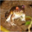

In [9]:
X_train[0]

In [10]:
X_train[0].shape #know what vector gets passed here in more detail

(32, 32, 3)

In [11]:
X_train[0:5]

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [12]:
X_train[0][0]

array([[ 59,  62,  63],
       [ 43,  46,  45],
       [ 50,  48,  43],
       [ 68,  54,  42],
       [ 98,  73,  52],
       [119,  91,  63],
       [139, 107,  75],
       [145, 110,  80],
       [149, 117,  89],
       [149, 120,  93],
       [131, 103,  77],
       [125,  99,  76],
       [142, 115,  91],
       [144, 112,  86],
       [137, 105,  79],
       [129,  97,  71],
       [137, 106,  79],
       [134, 106,  76],
       [124,  97,  64],
       [139, 113,  78],
       [139, 112,  75],
       [133, 105,  69],
       [136, 105,  74],
       [139, 108,  77],
       [152, 120,  89],
       [163, 131, 100],
       [168, 136, 108],
       [159, 129, 102],
       [158, 130, 104],
       [158, 132, 108],
       [152, 125, 102],
       [148, 124, 103]], dtype=uint8)

In [13]:
X_train[0][0][0]

array([59, 62, 63], dtype=uint8)

In [14]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

Understand here that X are the RAW values and y are the labels for those RAW values. and hence we can do this checking kinda thing.


It also beautifully plots itself in the matplotlib plotting, hence proving the beauty behind the how the machine learns - Kudos to the engineers who actually made this

In [15]:
def plot_sample(index):
  plt.figure(figsize = (10, 1))
  plt.imshow(X_train[index])

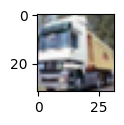

In [16]:
plot_sample(1)

In [17]:
X_train_scaled = X_train/255
Y_train_scaled = X_test/255


Turning number of clases into categorical values


In [20]:
y_train_categorical = keras.utils.to_categorical(
    y_train, num_classes=10
)

y_train_categorical[:5] #for 6 we have '1' at 6th place. #what flatten, why category ?, what is the neural netwoek sstructure, how to keep this algorithm in my mind. how are the arrays getting processed here to be honest ?


array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [21]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32, 3)),
    #Output is 10 neurons because of 10 features.
    #we use sigmoid because they are good with the classification
    keras.layers.Dense(3000, activation='relu'),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile('SGD',
              loss='categorical_crossentropy', #sparse vs categorical, Neuron differnece and why one hot encoding done here at all anyways
              metrics=['accuracy']
              )

model.fit(X_train_scaled, y_train_categorical, epochs=50)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.3047 - loss: 1.9295
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 53ms/step - accuracy: 0.4194 - loss: 1.6386
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 50ms/step - accuracy: 0.4533 - loss: 1.5505
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.4790 - loss: 1.4776
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.4979 - loss: 1.4366
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.5141 - loss: 1.3918
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.5254 - loss: 1.3472
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 49ms/step - accuracy: 0.5377 - loss: 1.3115
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 53ms/step - accuracy: 0.5494 - loss: 1.2798
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.5610 - loss: 1.2530
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.5738 - loss: 1.2246
Epoch

In [ ]:
model.predict(X_test_scaled)[0]

In [ ]:
y_test

In [23]:
def get_model():
  model = keras.Sequential([
      keras.layers.Flatten(input_shape=(32, 32, 3)),
      #Output is 10 neurons because of 10 features.
      #we use sigmoid because they are good with the classification
      keras.layers.Dense(3000, activation='relu'),
      keras.layers.Dense(1000, activation='relu'),
      keras.layers.Dense(10, activation='sigmoid')
  ])

  model.compile('SGD',
                loss='categorical_crossentropy', #sparse vs categorical, Neuron differnece and why one hot encoding done here at all anyways
                metrics=['accuracy']
                )

  model.fit(X_train_scaled, y_train_categorical, epochs=50)
  return model

In [ ]:
%timeit -n1 -r1 #used for measuring the times
with tf.device('/CPU:0'): #this is how we choose the things we want heremodel = keras.Sequential([
   cpu_model = get_model()
   cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

I'll give you the **definitive, exhaustive breakdown** that will permanently embed this in your neural pathways. Let's build this from the ground up with extreme precision.

***

## PART 1: THE DATA STRUCTURE - COMPLETE ANATOMICAL BREAKDOWN

Your CIFAR-10 dataset is a **4-dimensional tensor**: `(50000, 32, 32, 3)`[1][2]

```
X_train.shape = (50000, 32, 32, 3)
                  │      │   │   │
                  │      │   │   └─── RGB Channels (3 values per pixel)
                  │      │   └─────── Width (32 pixels across)
                  │      └─────────── Height (32 pixels down)
                  └────────────────── Number of images in dataset
```

### Visual Representation of ONE Image (32×32×3):

```
X_train[0] = A 3D CUBE of numbers

        Channel 0 (RED)              Channel 1 (GREEN)            Channel 2 (BLUE)
    ┌─────────────────────┐      ┌─────────────────────┐      ┌─────────────────────┐
  0 │ 59  43  50 ... (32) │    0 │ 62  46  53 ... (32) │    0 │ 63  47  54 ... (32) │
  1 │ 62  46  53 ...      │    1 │ 63  47  54 ...      │    1 │ 64  48  55 ...      │
  2 │ 63  47  54 ...      │    2 │ 64  48  55 ...      │    2 │ 65  49  56 ...      │
  . │  .   .   .          │    . │  .   .   .          │    . │  .   .   .          │
  . │  .   .   .          │    . │  .   .   .          │    . │  .   .   .          │
 31 │[32 values]          │   31 │[32 values]          │   31 │[32 values]          │
    └─────────────────────┘      └─────────────────────┘      └─────────────────────┘
         32×32 matrix                 32×32 matrix                 32×32 matrix
```

### Indexing Breakdown - THE CRITICAL MENTAL MODEL:

```
X_train[i][r][c][ch]
        │  │  │  │
        │  │  │  └──── Channel index (0=Red, 1=Green, 2=Blue)
        │  │  └─────── Column (horizontal position, 0-31)
        │  └────────── Row (vertical position, 0-31)
        └───────────── Image index (0-49999)

CONCRETE EXAMPLE:
X_train[0]         → Shape (32, 32, 3)   = "Give me the entire first image"
X_train[0][0]      → Shape (32, 3)       = "Give me the TOP ROW of pixels"
X_train[0][0][0]   → Shape (3,)          = "Give me the TOP-LEFT PIXEL's RGB"
                                            Result: [59, 62, 63]
X_train[0][0][0][0] → Scalar            = "Give me the RED value of top-left pixel"
                                            Result: 59
```

### The First Row Visualized:

```
X_train[0][0] = First row of 32 pixels

Pixel 0      Pixel 1      Pixel 2                    Pixel 31
[59,62,63]   [43,46,47]   [50,53,54]  ........  [?,?,?]
   RGB          RGB          RGB                    RGB

This is shape (32, 3) = 32 pixels, each with 3 color values
```

***

## PART 2: THE FLATTEN OPERATION - MATHEMATICAL TRANSFORMATION

**Input Shape**: (32, 32, 3) = 3,072 total values  
**Output Shape**: (3072,) = A single 1D vector[3][4]

### How Flatten Physically Rearranges Data:

```
BEFORE FLATTEN (3D Structure):

Layer 0 (Red Channel)        Layer 1 (Green)          Layer 2 (Blue)
Row 0: [59, 43, 50, ... ]    [62, 46, 53, ... ]      [63, 47, 54, ... ]
Row 1: [62, 46, 53, ... ]    [63, 47, 54, ... ]      [64, 48, 55, ... ]
...

AFTER FLATTEN (1D Vector):
Position:  0   1   2   3   4   5   6   ...  3069 3070 3071
Value:    [59, 62, 63, 43, 46, 47, 50, ...   ?,   ?,   ?  ]
          └─Pixel(0,0)─┘ └─Pixel(0,1)─┘
          R   G   B      R   G   B

Reading Order: Row-by-row, left-to-right, all channels for each pixel
```

### The Algorithm (Pseudocode):

```python
flattened_array = []
for row in range(32):
    for col in range(32):
        for channel in range(3):
            flattened_array.append(X_train[0][row][col][channel])

# Result: 32 × 32 × 3 = 3,072 values in a single line
```

**Why This Matters**: Dense layers perform matrix multiplication, which requires 1D inputs. A 3D structure can't be multiplied with a weight matrix—it must be linearized.[5][6]

***

## PART 3: NEURAL NETWORK ARCHITECTURE - COMPLETE DIMENSIONAL ANALYSIS

```
INPUT          FLATTEN       DENSE-1 (3000)    DENSE-2 (1000)   OUTPUT (10)
IMAGE          LAYER         ReLU              ReLU             Sigmoid
─────────────────────────────────────────────────────────────────────────

(32,32,3)  →   (3072,)   →   (3000,)      →    (1000,)     →    (10,)
3D Cube        1D Vector     1D Vector         1D Vector        1D Vector

              ┌─────┐       ┌─────┐          ┌─────┐          ┌─────┐
              │  .  │       │  .  │          │  .  │          │  0  │ Airplane
              │  .  │       │  .  │          │  .  │          │  1  │ Automobile
              │ 3072│───────│ 3000│──────────│ 1000│──────────│  2  │ Bird
              │ vals│       │neur.│          │neur.│          │  3  │ Cat
              │  .  │       │  .  │          │  .  │          │  .  │ ...
              │  .  │       │  .  │          │  .  │          │  9  │ Truck
              └─────┘       └─────┘          └─────┘          └─────┘

Parameters:   3072×3000    3000×1000         1000×10
             = 9,216,000  = 3,000,000        = 10,000
             + 3,000 bias + 1,000 bias       + 10 bias
```

### Weight Matrix Dimensions - THE FORMULA

For a Dense layer connecting `N_in` neurons to `N_out` neurons:[7][8]

```
Weight Matrix Shape: (N_in, N_out)

Layer 1: (3072, 3000)  ← Each of 3000 neurons receives all 3072 inputs
Layer 2: (3000, 1000)  ← Each of 1000 neurons receives all 3000 inputs
Layer 3: (1000, 10)    ← Each of 10 neurons receives all 1000 inputs
```

***

## PART 4: FORWARD PROPAGATION - THE COMPLETE MATHEMATICAL JOURNEY

### Single Neuron Computation (The Atomic Unit):

```
                    INPUTS (from previous layer)
                    x₁, x₂, x₃, ..., xₙ
                    │   │   │       │
                    ↓   ↓   ↓       ↓
                   w₁  w₂  w₃ ...  wₙ  (Learned Weights)
                    │   │   │       │
                    └───┴───┴───────┘
                          ↓
                    Σ (x₁w₁ + x₂w₂ + ... + xₙwₙ + b)
                          ↓
                   Activation Function (ReLU or Sigmoid)
                          ↓
                        OUTPUT

Mathematical Formula:
output = activation(Σᵢ(xᵢ × wᵢ) + bias)
```

### Concrete Example - First Neuron in Layer 1:

```
Input (after scaling): [0.231, 0.243, 0.247, ..., (3072 values)]
Weights (random init): [0.05, -0.03, 0.08, ..., (3072 values)]
Bias: 0.1

Step 1 - Weighted Sum:
z = (0.231 × 0.05) + (0.243 × -0.03) + (0.247 × 0.08) + ... + 0.1
z = 0.01155 - 0.00729 + 0.01976 + ... + 0.1
z = -0.523 (example result)

Step 2 - ReLU Activation:
ReLU(z) = max(0, z) = max(0, -0.523) = 0

Output of this neuron: 0
```

### Complete Layer-by-Layer Transformation:

```
INPUT (Scaled):        [0.231, 0.243, ..., 0.198]  (3072 values, range 0-1)
                                  ↓
                         ┌────────────────┐
                         │  DENSE LAYER 1 │
                         │  3000 neurons  │
                         └────────────────┘
                       Each neuron does:
                       z = Σ(input × weight) + bias
                       output = ReLU(z) = max(0, z)
                                  ↓
HIDDEN LAYER 1:        [0.0, 2.34, 0.0, 1.87, ...]  (3000 values)
                                  ↓
                         ┌────────────────┐
                         │  DENSE LAYER 2 │
                         │  1000 neurons  │
                         └────────────────┘
                       Same process with 3000 inputs
                                  ↓
HIDDEN LAYER 2:        [0.0, 0.0, 3.21, 0.0, ...]   (1000 values)
                                  ↓
                         ┌────────────────┐
                         │  OUTPUT LAYER  │
                         │   10 neurons   │
                         │    Sigmoid     │
                         └────────────────┘
                       z = Σ(input × weight) + bias
                       output = sigmoid(z) = 1/(1+e^(-z))
                                  ↓
OUTPUT (Predictions):  [0.02, 0.01, 0.85, 0.03, ...]  (10 values, range 0-1)
                        └───┘      └───┘
                      Not frog   Probably frog! (class 2)
```

### Matrix Multiplication View:[1][5]

```
Input Vector (X):      Shape (3072, 1)
Weight Matrix (W₁):    Shape (3072, 3000)
Bias Vector (b₁):      Shape (3000, 1)

Z₁ = W₁ᵀ × X + b₁      Shape (3000, 1)
A₁ = ReLU(Z₁)          Shape (3000, 1)

Then:
Z₂ = W₂ᵀ × A₁ + b₂     Shape (1000, 1)
A₂ = ReLU(Z₂)          Shape (1000, 1)

Finally:
Z₃ = W₃ᵀ × A₂ + b₃     Shape (10, 1)
Output = Sigmoid(Z₃)   Shape (10, 1)
```

***

## PART 5: ONE-HOT ENCODING - WHY AND HOW

### The Problem:

```
Original Label: y_train[5] = [6]  (Just the integer 6 = "frog")

Your output layer produces:
[0.02, 0.01, 0.85, 0.03, 0.05, 0.01, 0.02, 0.00, 0.01, 0.00]

How do you compare a single integer with 10 probabilities? YOU CAN'T.
```

### The Solution - One-Hot Encoding:[9]

```
BEFORE (Sparse Format):
y_train[0] = 6        (Integer - cat)
y_train[1] = 9        (Integer - truck)
y_train[2] = 9        (Integer - truck)

AFTER (One-Hot Categorical Format):
y_train_categorical[0] = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]  ← 1 at position 6
y_train_categorical[1] = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]  ← 1 at position 9
y_train_categorical[2] = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]  ← 1 at position 9

Class Mapping:
Position:  0         1         2      3    4     5     6     7     8    9
Class:  [airplane, auto, bird, cat, deer, dog, frog, horse, ship, truck]
```

### Why This Structure Matches Your Network:

```
Your Output Layer:     Target Label (One-Hot):
┌───────────────┐      ┌───────────────┐
│ Neuron 0: 0.02│      │ Position 0: 0 │
│ Neuron 1: 0.01│      │ Position 1: 0 │
│ Neuron 2: 0.85│  VS  │ Position 2: 0 │
│ Neuron 3: 0.03│      │ Position 3: 0 │
│ Neuron 4: 0.05│      │ Position 4: 0 │
│ Neuron 5: 0.01│      │ Position 5: 0 │
│ Neuron 6: 0.02│      │ Position 6: 1 │ ← TRUE CLASS
│ Neuron 7: 0.00│      │ Position 7: 0 │
│ Neuron 8: 0.01│      │ Position 8: 0 │
│ Neuron 9: 0.00│      │ Position 9: 0 │
└───────────────┘      └───────────────┘

Now they're STRUCTURALLY IDENTICAL - both are 10-element vectors!
```

### Categorical vs Sparse Categorical Crossentropy:[9]

```
CATEGORICAL CROSSENTROPY (What you used):
- Expects labels as one-hot vectors: [0,0,0,0,0,0,1,0,0,0]
- Loss = -Σ(target_i × log(prediction_i))
- Loss = -(0×log(0.02) + ... + 1×log(0.02) + ... + 0×log(0.00))
- Only the position with '1' contributes: Loss = -log(0.02) = 3.91

SPARSE CATEGORICAL CROSSENTROPY (Alternative):
- Expects labels as integers: 6
- Internally converts to one-hot, then calculates same formula
- Result: IDENTICAL loss value = 3.91

You manually converted with to_categorical(), so you must use categorical_crossentropy.
```

***

## PART 6: BACKPROPAGATION - HOW LEARNING HAPPENS

### The Complete Learning Cycle:[10][11]

```
EPOCH 1, Sample 1:

1. FORWARD PASS:
   Input: Frog image → Network → Output: [0.02, 0.01, 0.85, ...]
   Target:                                [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
                                                        ↑
                                                      Frog is class 6

2. COMPUTE LOSS:
   Categorical Crossentropy = -log(prediction[6]) = -log(0.02) = 3.91
   (High loss = bad prediction)

3. BACKPROPAGATION (Moving Backward):
   
   Output Layer Error:
   δ_output = (prediction - target) = [0.02, 0.01, 0.85, ...] - [0,0,0,0,0,0,1,0,0,0]
            = [0.02, 0.01, -0.15, ...]  ← Negative means "increase this neuron"
   
   Hidden Layer 2 Error:
   δ_hidden2 = (W_output^T × δ_output) × ReLU'(Z_hidden2)
   (Error propagates backward through weights)
   
   Hidden Layer 1 Error:
   δ_hidden1 = (W_hidden2^T × δ_hidden2) × ReLU'(Z_hidden1)

4. GRADIENT CALCULATION [web:15]:
   
   For each weight w_ij connecting neuron i to neuron j:
   ∂Loss/∂w_ij = δ_j × activation_i
   
   Example for weight from input neuron 500 to hidden neuron 1200:
   gradient = δ_hidden1[1200] × input[500]
            = -0.0034 × 0.231
            = -0.000785

5. WEIGHT UPDATE (Gradient Descent):
   
   w_new = w_old - learning_rate × gradient
   
   If w_old = 0.05, learning_rate = 0.01:
   w_new = 0.05 - 0.01 × (-0.000785)
         = 0.05 + 0.00000785
         = 0.05000785
   
   (Slightly increased because gradient was negative = loss wants this weight bigger)
```

### Visual Flow of Gradients:

```
FORWARD (Data flows →):
Input → Layer1 → Layer2 → Output → Loss

BACKWARD (Gradients flow ←):
Input ← Layer1 ← Layer2 ← Output ← Loss
        ↑        ↑        ↑
     Update   Update   Update
     Weights  Weights  Weights
```

***

## PART 7: THE COMPLETE DATA FLOW - END TO END

```
╔═══════════════════════════════════════════════════════════════════════════╗
║                        COMPLETE NEURAL NETWORK FLOW                        ║
╚═══════════════════════════════════════════════════════════════════════════╝

STEP 1: RAW IMAGE DATA
─────────────────────────
X_train[0] → 32×32×3 array of integers [0-255]
[[[ 59,  62,  63],  [ 43,  46,  47], ...],    ← Row 0
 [[ 62,  63,  64],  [ 46,  47,  48], ...],    ← Row 1
 ...]                                          ← ... Row 31

STEP 2: NORMALIZATION
─────────────────────────
X_train_scaled = X_train / 255  → Values now [0.0-1.0]
Why? Keeps gradients stable, prevents exploding/vanishing values

STEP 3: FLATTEN
─────────────────────────
(32, 32, 3) → (3072,)
[0.231, 0.243, 0.247, 0.169, ..., 0.198]
↑       ↑       ↑       ↑
Pixel   Pixel   Pixel   Pixel
(0,0)R  (0,0)G  (0,0)B  (0,1)R

STEP 4: FIRST DENSE LAYER (3000 neurons)
─────────────────────────────────────────
Each neuron computes:
z = w₁×0.231 + w₂×0.243 + ... + w₃₀₇₂×0.198 + bias
output = max(0, z)  [ReLU activation]

Result: 3000 values representing learned features

STEP 5: SECOND DENSE LAYER (1000 neurons)
──────────────────────────────────────────
Takes 3000 inputs, computes 1000 outputs
More abstract feature combinations

STEP 6: OUTPUT LAYER (10 neurons, Sigmoid)
──────────────────────────────────────────
output[i] = 1 / (1 + e^(-z[i]))  → Range [0, 1]
[0.02, 0.01, 0.85, 0.03, 0.05, 0.01, 0.02, 0.00, 0.01, 0.00]
  ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑     ↑
plane auto  bird  cat  deer  dog  frog horse ship truck

Prediction: Class 2 (bird) with 85% confidence

STEP 7: COMPARE WITH TARGET
────────────────────────────
Predicted: [0.02, 0.01, 0.85, 0.03, 0.05, 0.01, 0.02, 0.00, 0.01, 0.00]
True:      [0,    0,    0,    0,    0,    0,    1,    0,    0,    0   ]
                                              ↑
                                          Should be frog!

Loss = categorical_crossentropy = 3.91 (high error)

STEP 8: BACKPROPAGATION
───────────────────────
Calculate: How much should each of 12+ million weights change?
Adjust weights to make neuron 6 stronger, neuron 2 weaker

STEP 9: REPEAT
──────────────
Do this for all 50,000 images, 50 times (epochs)
Weights gradually learn: "These pixel patterns = frog"
```

***

## PART 8: THE INTUITIVE MENTAL MODEL - PERMANENT MEMORY HOOKS

### Think of it Like This:

```
1. IMAGE = A BOOK OF 3 PAGES (RGB channels)
   Each page has 32×32 = 1,024 numbers
   
2. FLATTEN = READING THE BOOK LINE-BY-LINE INTO ONE SENTENCE
   3,072 words in sequence
   
3. LAYER 1 (3000 neurons) = 3000 PATTERN DETECTORS
   Each detector looks at ALL 3,072 values and says:
   "Does this look like an edge?" → Output: 2.3
   "Does this look like a curve?" → Output: 0.0
   "Does this look like texture?" → Output: 1.7
   
4. LAYER 2 (1000 neurons) = 1000 FEATURE COMBINERS
   "I see edges + curves = maybe a wheel?" → Output: 3.1
   "I see texture + green = maybe grass?" → Output: 0.0
   
5. OUTPUT (10 neurons) = 10 CLASS VOTERS
   Neuron 6 says: "Based on all features, 85% sure this is a FROG"
   
6. ONE-HOT ENCODING = THE ANSWER KEY
   [0,0,0,0,0,0,1,0,0,0] = "It's definitely a frog (class 6)"
   
7. LOSS = REPORT CARD
   "You said bird (85%), but it's frog. You're wrong by 3.91 units"
   
8. BACKPROPAGATION = LEARNING FROM MISTAKES
   "Next time, I'll pay more attention to green skin texture and less to blue sky"
```

### The Weight Matrix Intuition:

```
Imagine 3,072 light switches (inputs) and 3,000 light bulbs (neurons in layer 1).

EACH bulb is connected to ALL 3,072 switches.
Each wire has a STRENGTH (weight).

When switch 500 is ON (bright pixel), it might:
- Strongly turn ON bulb 1200 (weight = +0.8)
- Slightly turn OFF bulb 1500 (weight = -0.2)
- Not affect bulb 2000 (weight = 0.0)

Learning = Adjusting these 9+ million wire strengths so the bulbs light up in patterns
that represent "this is a frog" when frog images come in.
```

***

## FINAL MENTAL CHECKLIST - BURN THIS IN:

✓ **Array indexing**: `[image][row][column][channel]` - always this order  
✓ **Flatten**: 3D cube → 1D line (reading order: row-by-row, all channels per pixel)  
✓ **Weight shape**: `(inputs, outputs)` - connects every input to every output  
✓ **Forward pass**: Input × Weights + Bias → Activation → Next layer  
✓ **One-hot**: Convert class integer to vector so it matches output shape  
✓ **Loss**: Measures "how wrong" by comparing output vector to target vector  
✓ **Backprop**: Calculate gradients (how much to change each weight) by moving backward  
✓ **Gradient descent**: `weight_new = weight_old - learning_rate × gradient`  

This structure is **universal**—it applies to MNIST, ImageNet, text, audio, anything. Master this, and you can construct any feedforward network intuitively.[5][1]

[1](https://www.datacamp.com/tutorial/forward-propagation-neural-networks)
[2](https://www.geeksforgeeks.org/deep-learning/what-is-forward-propagation-in-neural-networks/)
[3](https://www.educative.io/answers/what-is-a-neural-network-flatten-layer)
[4](https://stackoverflow.com/questions/43237124/what-is-the-role-of-flatten-in-keras)
[5](https://andrew.gibiansky.com/blog/machine-learning/fully-connected-neural-networks/)
[6](https://www.adityaagrawal.net/blog/deep_learning/bprop_fc)
[7](https://stackoverflow.com/questions/62310950/dimension-of-dense-layer-weight-matrix)
[8](https://wandb.ai/ayush-thakur/keras-dense/reports/Keras-Dense-Layer-How-to-Use-It-Correctly--Vmlldzo0MjAzNDY1)
[9](https://community.deeplearning.ai/t/categorical-crossentropy-vs-sparse-categorical-crossentropy/281808)
[10](https://www.geeksforgeeks.org/data-science/how-does-gradient-descent-and-backpropagation-work-together/)
[11](https://en.wikipedia.org/wiki/Backpropagation)
[12](http://d2l.ai/chapter_multilayer-perceptrons/backprop.html)
[13](https://blog.quantinsti.com/forward-propagation-neural-networks/)

Let me clear up BOTH your confusions with absolute precision.

***

## CONFUSION 1: CHANNELS AND FLATTEN - THE CRITICAL MISUNDERSTANDING

You're worried that flatten "combines" the RGB values. **IT DOES NOT COMBINE ANYTHING**. Flatten just **reorders** the data into a single line while keeping **every single value separate and intact**.[1][2]

### What You're Confused About:

When you see a pixel like `[0, 245, 255]`, you might think:
- "Does flatten turn this into ONE number somehow?"
- "Do the channels get mixed together?"

**ANSWER: NO! Those three numbers stay as THREE SEPARATE VALUES.**

### The Exact Transformation:

```
BEFORE FLATTEN:
Shape: (32, 32, 3) = A 3D structure

X_train[0][0][0] = [59, 62, 63]  ← Pixel at position (row=0, col=0)
                    │   │   │
                    R   G   B    (THREE separate numbers)

X_train[0][0][1] = [43, 46, 47]  ← Pixel at position (row=0, col=1)
                    │   │   │
                    R   G   B


AFTER FLATTEN:
Shape: (3072,) = A 1D line

Position 0:  59   ← Red of pixel(0,0)
Position 1:  62   ← Green of pixel(0,0)  
Position 2:  63   ← Blue of pixel(0,0)
Position 3:  43   ← Red of pixel(0,1)
Position 4:  46   ← Green of pixel(0,1)
Position 5:  47   ← Blue of pixel(0,1)
Position 6:  50   ← Red of pixel(0,2)
...
Position 3071: ??? ← Blue of pixel(31,31)
```

### The Key Insight:

```
YOUR PIXEL: [0, 245, 255]

BEFORE FLATTEN (stored in 3D array):
- X_train[0][row][col][0] = 0     (Red channel)
- X_train[0][row][col][1] = 245   (Green channel)
- X_train[0][row][col][2] = 255   (Blue channel)

AFTER FLATTEN (stored in 1D array):
Let's say this pixel was at row=5, col=10:
- Position = (5 × 32 × 3) + (10 × 3) + 0 = 480
- flattened[480] = 0      ← Still the Red value!
- flattened[481] = 245    ← Still the Green value!
- flattened[482] = 255    ← Still the Blue value!

NOTHING COMBINED! Just reordered into a line.
```

### Why This Matters:

Flatten **does NOT lose any information**. It's like taking a Rubik's cube and unfolding it into a single strip - all the colored squares are still there, just arranged differently.

```
3D CUBE (hard to process):          1D LINE (easy to process):
    ┌───┐                            ┌─┬─┬─┬─┬─┬─┬─┬─┬─┐
   ╱   ╱│                            │ │ │ │ │ │ │ │ │ │
  ┌───┐ │     FLATTEN →              └─┴─┴─┴─┴─┴─┴─┴─┴─┘
  │   │ │                            All values preserved
  │   │╱                             Just different arrangement
  └───┘
```

### The Formula for Position After Flatten:

```
For a pixel at position (row, col, channel) in shape (32, 32, 3):

Position in flattened array = (row × 32 × 3) + (col × 3) + channel

Example pixel at row=15, col=20, RED channel:
Position = (15 × 96) + (20 × 3) + 0 = 1440 + 60 + 0 = 1500

So: flattened[1500] contains the red value of pixel(15,20)
    flattened[1501] contains the green value of pixel(15,20)
    flattened[1502] contains the blue value of pixel(15,20)
```

**Flatten does NOT segregate or combine - it just LINEARIZES the data.**

***

## CONFUSION 2: ONE-HOT ENCODING - YES, YOU'RE RIGHT!

**One-hot encoding is applied to the LABELS (y_train), NOT the images (X_train)**.[6][1]

### What Gets One-Hot Encoded:

```
INPUT IMAGES (X_train):
- Shape: (50000, 32, 32, 3)
- NO one-hot encoding needed
- Just normalize: X_train_scaled = X_train / 255

OUTPUT LABELS (y_train):
- Original shape: (50000, 1) with integers [0-9]
- GETS one-hot encoded → (50000, 10)
- Each label becomes a 10-element vector
```

### Why One-Hot Encode the Output Labels?

Your neural network output layer has **10 neurons** producing 10 values like:
```
[0.02, 0.01, 0.85, 0.03, 0.05, 0.01, 0.02, 0.00, 0.01, 0.00]
```

To calculate loss, you need the **true label in the same format**:[1][6]

```
BEFORE ONE-HOT ENCODING:
y_train[5] = 6  (just an integer)

How do you compare:
  [0.02, 0.01, 0.85, ...] (network output - 10 values)
with
  6 (true label - 1 value)  ???

YOU CAN'T! Different dimensions!

AFTER ONE-HOT ENCODING:
y_train_categorical[5] = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

Now you can compare:
  [0.02, 0.01, 0.85, 0.03, 0.05, 0.01, 0.02, 0.00, 0.01, 0.00]  (predicted)
with
  [0,    0,    0,    0,    0,    0,    1,    0,    0,    0   ]  (true)
  
Both are 10-element vectors! Now loss calculation works:
Loss = -sum(true × log(predicted))
     = -(0×log(0.02) + ... + 1×log(0.02) + ... + 0×log(0.00))
     = -log(0.02) = 3.91
```

### The Complete Picture:

```
X_train (IMAGES):          y_train (LABELS):
Shape: (50000,32,32,3)     Shape: (50000,1) → integers [0-9]
                                    ↓
Normalize ÷ 255            One-Hot Encode with to_categorical()
      ↓                              ↓
(50000,32,32,3)            Shape: (50000,10) → binary vectors
      ↓                              ↓
Flatten layer              [0,0,0,0,0,0,1,0,0,0]
      ↓                              ↓
(50000,3072)               Used as TARGET in loss function
      ↓
Dense layers
      ↓
Output: (50000,10)  ← Must match target shape!
```

***

## SUMMARY - LOCK THIS IN:

1. **Flatten PRESERVES all values** - it just reorders them from 3D to 1D. Your `[0, 245, 255]` becomes three separate entries: `...0, 245, 255...` in the flattened array.

2. **One-hot encoding is for OUTPUT LABELS (y_train) ONLY**, not input images. It converts integer class labels into binary vectors that match your network's 10-neuron output structure.[8][6][1]

3. **Nothing gets "combined"** - every RGB value stays distinct throughout the entire pipeline. Flatten just changes the **storage format**, not the **data content**.

[1](https://stackoverflow.com/questions/51384911/one-hot-encoding-of-output-labels)
[2](https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/)
[3](https://discuss.pytorch.org/t/how-do-i-one-hot-encode-my-outputs-in-a-simple-neural-network/119283)
[4](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/)
[5](https://stackoverflow.com/questions/73271013/difference-between-one-hot-encoding-and-label-encoding-of-target-output-label)
[6](https://eitca.org/artificial-intelligence/eitc-ai-dltf-deep-learning-with-tensorflow/using-convolutional-neural-network-to-identify-dogs-vs-cats/introduction-and-preprocessing/examination-review-introduction-and-preprocessing/how-are-the-labels-for-the-images-represented-using-one-hot-encoding/)
[7](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
[8](https://eitca.org/artificial-intelligence/eitc-ai-tff-tensorflow-fundamentals/natural-language-processing-with-tensorflow/training-ai-to-create-poetry/examination-review-training-ai-to-create-poetry/why-is-one-hot-encoding-used-for-the-output-labels-in-training-the-ai-model/)
[9](https://forums.fast.ai/t/to-label-encode-or-one-hot-encode/6057)
[10](https://www.kaggle.com/code/marcinrutecki/one-hot-encoding-everything-you-need-to-know)